# IV. Multivariate Analysis

This notebook evaluates campaign performance using multivariate techniques on the cleaned dataset.
The goal is to understand how multiple features interact and jointly explain ROI and conversion behavior.

## Step 1: Imports and Visualization Setup

In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Shared dark-theme plotting defaults to match notebook 3 outputs.
plt.style.use("dark_background")
sns.set_theme(style="darkgrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.facecolor"] = "#121212"
plt.rcParams["figure.facecolor"] = "#121212"
plt.rcParams["savefig.facecolor"] = "#121212"
plt.rcParams["savefig.edgecolor"] = "#121212"
plt.rcParams["axes.edgecolor"] = "#E0E0E0"
plt.rcParams["axes.labelcolor"] = "#F5F5F5"
plt.rcParams["xtick.color"] = "#E0E0E0"
plt.rcParams["ytick.color"] = "#E0E0E0"
plt.rcParams["text.color"] = "#F5F5F5"
plt.rcParams["grid.color"] = "#3A3A3A"

## Expand display width so wide tables remain readable in notebook output.
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

## Step 2: Load Cleaned Dataset

In [18]:
## Define expected cleaned dataset path and output folder for exported artifacts.
cleaned_dataset_path = Path("../datasets/marketing_campaign_dataset_cleaned.csv")
results_dir = Path("../results/multivariate_analysis")

## Ensure export directory exists before writing charts/tables.
results_dir.mkdir(parents=True, exist_ok=True)

## Stop early with a clear dependency message if the input file is missing.
if not cleaned_dataset_path.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found at: {cleaned_dataset_path.resolve()}\n"
        "Run 02_clean_and_validate.ipynb first to generate the cleaned data."
    )

## Parse `Date` on load so time-based analyses can run without extra casting.
df = pd.read_csv(cleaned_dataset_path, parse_dates=["Date"])

print(f"Loaded dataframe shape: {df.shape}")
print(f"Source file: {cleaned_dataset_path.resolve()}")
print(f"Charts and summaries will be saved to: {results_dir.resolve()}")
## Quick preview to confirm columns before feature engineering.
df.head()

FileNotFoundError: Cleaned dataset not found at: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\datasets\marketing_campaign_dataset_cleaned.csv
Run 02_clean_and_validate.ipynb first to generate the cleaned data.

## Step 3: Build Multivariate Modeling Dataset

Prepare numeric predictors and encoded categorical signals for multivariate analysis.

In [ ]:
## Regression target for supervised modeling.
target = "ROI"

## Numeric predictors used directly in model fitting.
numeric_features = [
    "Conversion_Rate",
    "Acquisition_Cost",
    "Clicks",
    "Impressions",
    "Engagement_Score",
    "Duration",
]

## Categorical predictors to be one-hot encoded.
categorical_features = ["Channel_Used", "Campaign_Type", "Target_Audience", "Customer_Segment"]

## Validate schema before any feature construction.
required = [target, *numeric_features, *categorical_features]
missing_required = [c for c in required if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns for multivariate analysis: {missing_required}")

## Keep only modeling columns and drop incomplete rows.
model_df = df[required].copy()
model_df = model_df.dropna().reset_index(drop=True)

## Build final design matrix: numeric features + encoded categoricals.
X_num = model_df[numeric_features].copy()
X_cat = pd.get_dummies(model_df[categorical_features], drop_first=True)
X = pd.concat([X_num, X_cat], axis=1)
y = model_df[target].astype(float)

print(f"Rows used for modeling: {len(model_df)}")
print(f"Total predictors after encoding: {X.shape[1]}")
X.head()

Rows used for modeling: 200000
Total predictors after encoding: 23


,Conversion_Rate,Acquisition_Cost,Clicks,Impressions,Engagement_Score,Duration,Channel_Used_Facebook,Channel_Used_Google Ads,Channel_Used_Instagram,Channel_Used_Website,Channel_Used_YouTube,Campaign_Type_Email,Campaign_Type_Influencer,Campaign_Type_Search,Campaign_Type_Social Media,Target_Audience_Men 18-24,Target_Audience_Men 25-34,Target_Audience_Women 25-34,Target_Audience_Women 35-44,Customer_Segment_Foodies,Customer_Segment_Health & Wellness,Customer_Segment_Outdoor Adventurers,Customer_Segment_Tech Enthusiasts
0,0.04,16174.0,506,1922,6,30,False,True,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False
1,0.12,11566.0,116,7523,7,60,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False
2,0.07,10200.0,584,7698,1,30,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False
3,0.11,12724.0,217,1820,7,60,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False
4,0.05,16452.0,379,4201,3,15,False,False,False,False,True,True,False,False,False,False,True,False,False,False,True,False,False


## Step 4: Multivariate Visualization (Pair Relationships)

A pairplot helps visualize relationships among several numeric variables simultaneously.

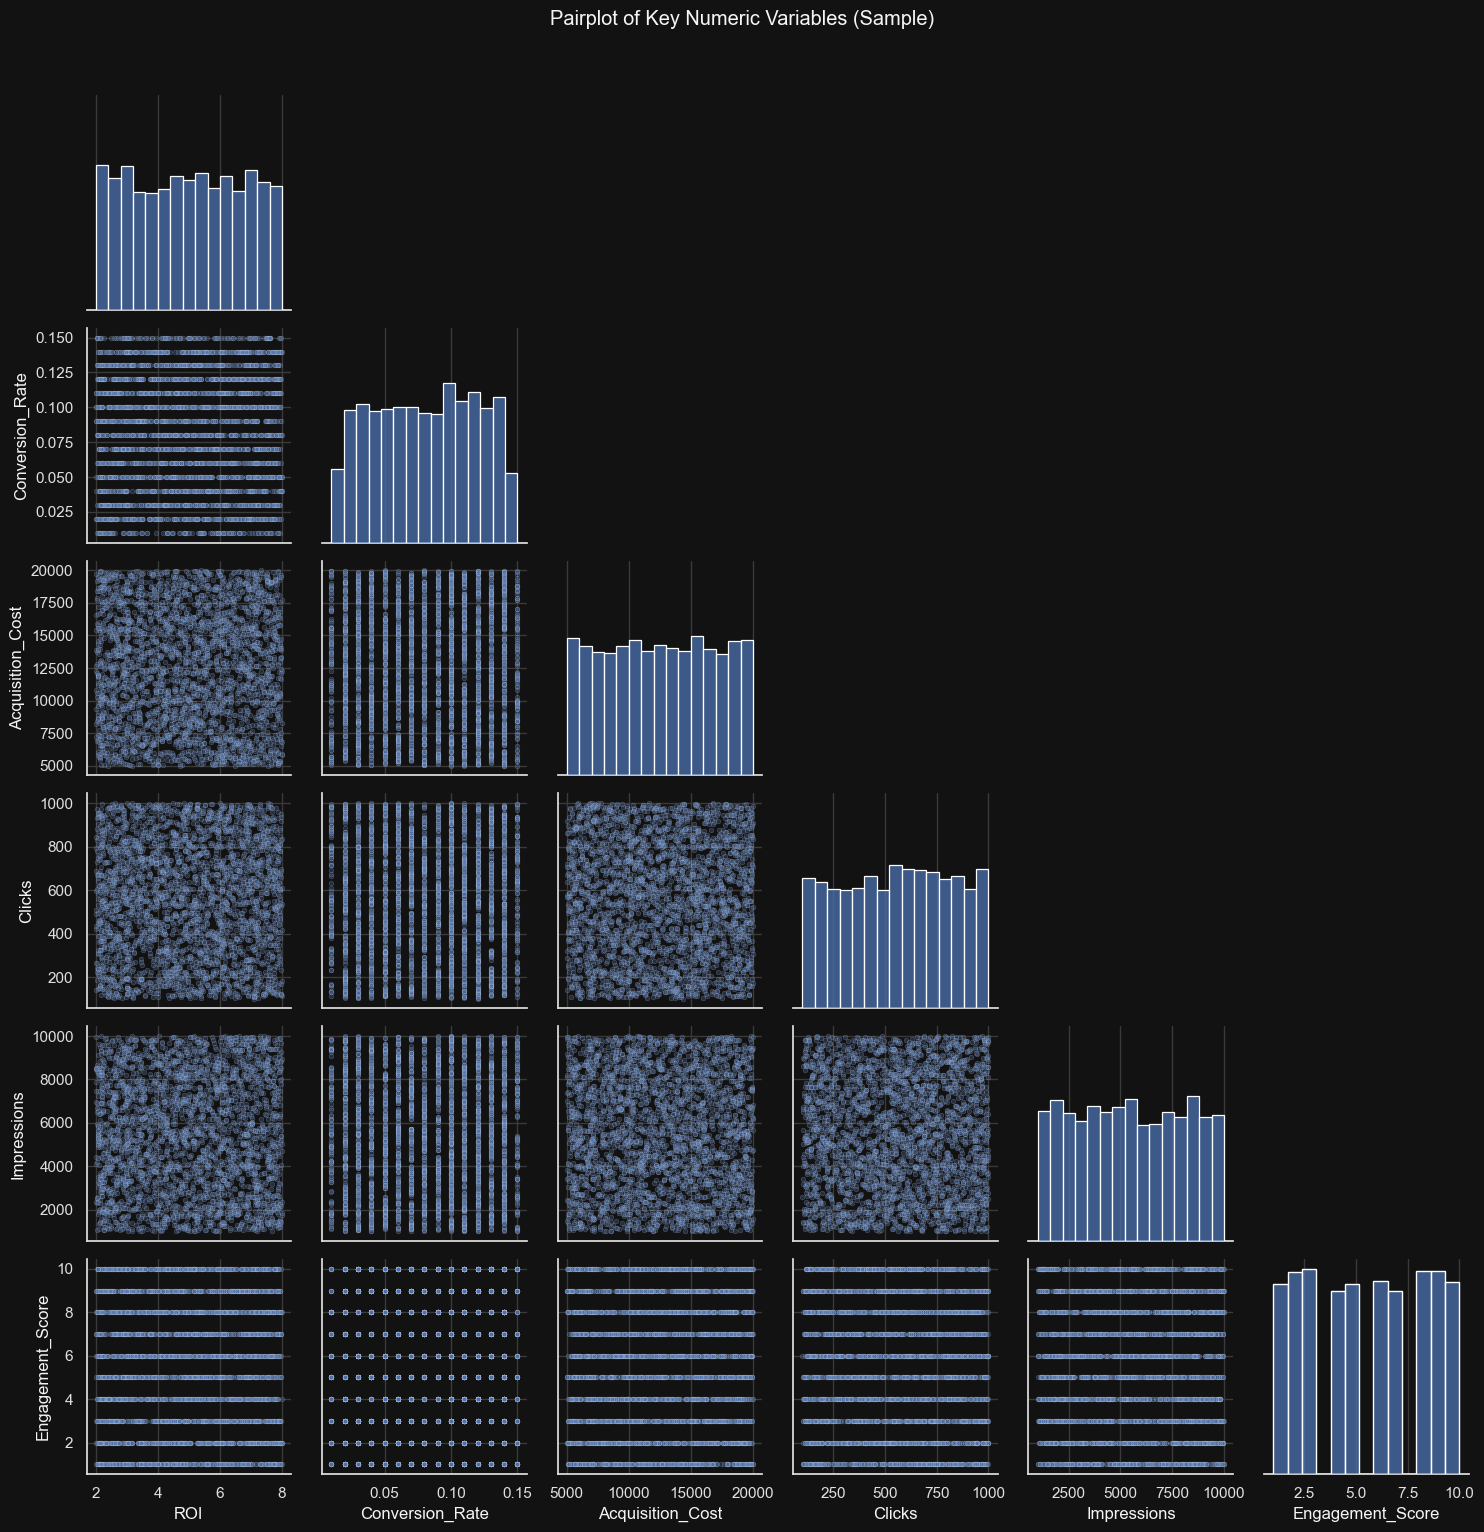

Saved: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\multivariate_analysis\pairplot_key_numeric_variables_dark.png


In [ ]:
## Core numeric columns for pairwise relationship inspection.
pair_cols = ["ROI", "Conversion_Rate", "Acquisition_Cost", "Clicks", "Impressions", "Engagement_Score"]

## Sample rows to keep pairplot readable and performant on larger datasets.
pair_df = model_df[pair_cols].sample(min(3000, len(model_df)), random_state=42)

pair_grid = sns.pairplot(pair_df, corner=True, diag_kind="hist", plot_kws={"alpha": 0.3, "s": 12})
pair_grid.fig.suptitle("Pairplot of Key Numeric Variables (Sample)", y=1.02)
pair_grid.fig.tight_layout()

pairplot_path = results_dir / "pairplot_key_numeric_variables_dark.png"
pair_grid.fig.savefig(pairplot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {pairplot_path.resolve()}")

## Step 5: Multiple Linear Regression for ROI

Fit a multivariate regression model where ROI is explained by multiple numeric and encoded categorical predictors.

In [ ]:
## Train/test split evaluates generalization on unseen data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Fit a baseline multiple linear regression model.
reg = LinearRegression()
reg.fit(X_train, y_train)

## Generate out-of-sample predictions on the test split.
y_pred = reg.predict(X_test)

## Report standard regression diagnostics.
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R^2:  {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

## Rank coefficients by absolute value for quick direction/strength inspection.
coef_df = pd.DataFrame({"feature": X.columns, "coefficient": reg.coef_})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

print("Top 15 coefficient magnitudes:")
coef_df.head(15)

R^2:  -0.0002
MAE:  1.5044
RMSE: 1.7367
Top 15 coefficient magnitudes:


,feature,coefficient,abs_coefficient
0,Conversion_Rate,-0.055820,0.055820
6,Channel_Used_Facebook,0.027553,0.027553
15,Target_Audience_Men 18-24,-0.022680,0.022680
16,Target_Audience_Men 25-34,0.019299,0.019299
14,Campaign_Type_Social Media,-0.017667,0.017667
9,Channel_Used_Website,0.013655,0.013655
10,Channel_Used_YouTube,-0.012885,0.012885
12,Campaign_Type_Influencer,0.012068,0.012068
13,Campaign_Type_Search,0.009158,0.009158
11,Campaign_Type_Email,-0.008976,0.008976


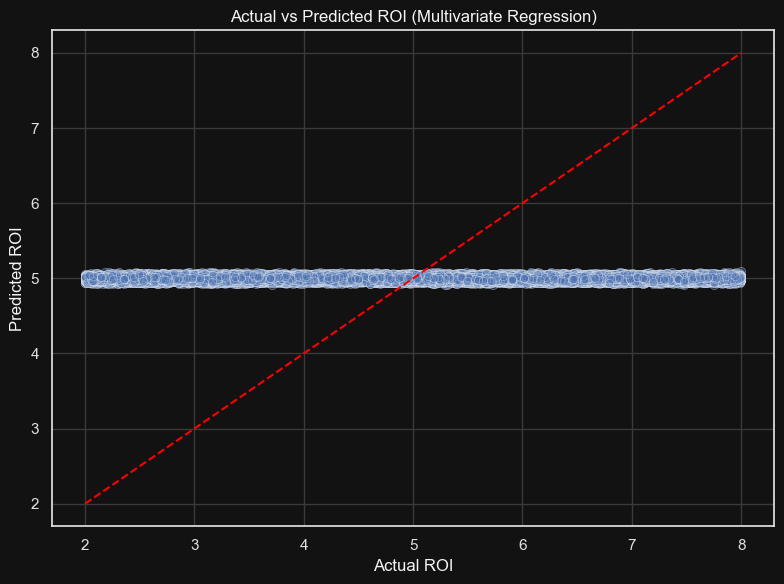

Saved: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\multivariate_analysis\actual_vs_predicted_roi_dark.png


In [ ]:
## Actual-vs-predicted scatter: tighter diagonal clustering implies better fit.
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
min_v = min(y_test.min(), y_pred.min())
max_v = max(y_test.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], color="red", linestyle="--", linewidth=1.5)
plt.title("Actual vs Predicted ROI (Multivariate Regression)")
plt.xlabel("Actual ROI")
plt.ylabel("Predicted ROI")
plt.tight_layout()

actual_vs_pred_path = results_dir / "actual_vs_predicted_roi_dark.png"
plt.savefig(actual_vs_pred_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {actual_vs_pred_path.resolve()}")

## Step 6: Customer/Campaign Segmentation with K-Means

Cluster campaigns on core performance metrics to identify multivariate behavioral segments.

Silhouette scores by K:


,k,silhouette_score
3,6,0.118286
2,5,0.117448
1,4,0.114122
0,3,0.110618


Selected K: 6
Silhouette sample size used: 20000


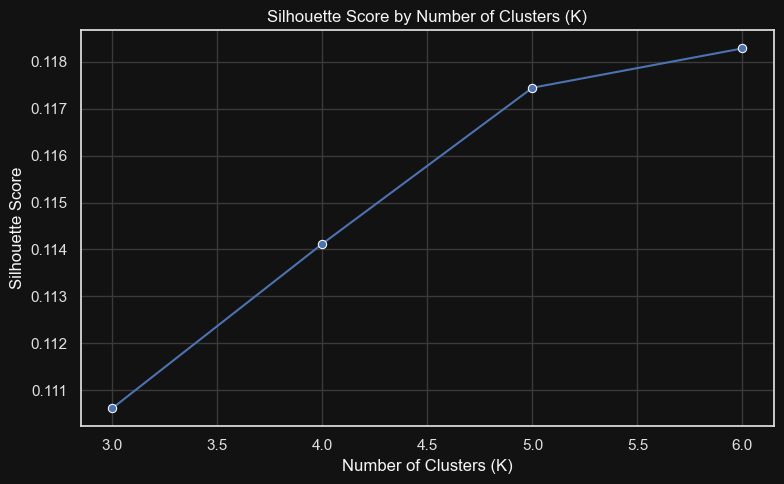

Saved: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\multivariate_analysis\silhouette_scores_by_k_dark.png


,Conversion_Rate,Acquisition_Cost,ROI,Clicks,Impressions,Engagement_Score,cluster
0,0.04,16174.0,6.29,506,1922,6,3
1,0.12,11566.0,5.61,116,7523,7,5
2,0.07,10200.0,7.18,584,7698,1,2
3,0.11,12724.0,5.55,217,1820,7,5
4,0.05,16452.0,6.50,379,4201,3,1


In [ ]:
## Numeric feature set for unsupervised segmentation.
cluster_features = ["Conversion_Rate", "Acquisition_Cost", "ROI", "Clicks", "Impressions", "Engagement_Score"]
cluster_df = model_df[cluster_features].dropna().copy()

## Standardize scale so distance-based clustering is not dominated by large-value columns.
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(cluster_df)

## Evaluate candidate K values and choose the highest silhouette score.
## Use a fixed sample for silhouette to keep runtime stable on large datasets.
candidate_k = [3, 4, 5, 6]
silhouette_sample_size = min(20000, len(cluster_df))
scores = []
for k in candidate_k:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_cluster_scaled)
    score = silhouette_score(
        X_cluster_scaled,
        labels,
        sample_size=silhouette_sample_size,
        random_state=42,
    )
    scores.append((k, score))

silhouette_df = pd.DataFrame(scores, columns=["k", "silhouette_score"]).sort_values("silhouette_score", ascending=False)
best_k = int(silhouette_df.iloc[0]["k"])

print("Silhouette scores by K:")
display(silhouette_df)
print(f"Selected K: {best_k}")
print(f"Silhouette sample size used: {silhouette_sample_size}")

## Save silhouette comparison chart for documentation/reporting.
plt.figure(figsize=(8, 5))
sns.lineplot(data=silhouette_df.sort_values("k"), x="k", y="silhouette_score", marker="o")
plt.title("Silhouette Score by Number of Clusters (K)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.tight_layout()

silhouette_plot_path = results_dir / "silhouette_scores_by_k_dark.png"
plt.savefig(silhouette_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {silhouette_plot_path.resolve()}")

## Fit final K-Means model and assign labels to each record.
kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=42)
cluster_df["cluster"] = kmeans.fit_predict(X_cluster_scaled)
cluster_df.head()

In [ ]:
## Cluster profile table summarizes central tendency and spread by segment.
cluster_profile = cluster_df.groupby("cluster").agg(["mean", "median", "std", "count"])
cluster_profile

Conversion_Rate                         Acquisition_Cost                                    ROI                          \
                   mean median       std  count             mean   median          std  count      mean median       std  count   
cluster                                                                                                                           
0              0.080362   0.08  0.040758  33559     10009.591555   9466.0  3428.851465  33559  3.504629   3.30  1.093377  33559   
1              0.078503   0.08  0.040658  33275     15976.416649  16529.0  2958.140540  33275  6.247983   6.46  1.228505  33275   
2              0.081518   0.08  0.040452  33112     10809.805901  10359.0  3758.713940  33112  6.356151   6.54  1.159329  33112   
3              0.080111   0.08  0.040555  33643     16084.531879  16562.0  2820.467155  33643  3.676652   3.47  1.198421  33643   
4              0.081023   0.08  0.040637  33424     13090.851215  13287.0  3992.708364  33424  4.953796   4.94  1.600222  33424   
5              0.078891   0.08  0.040463  32987      8995.563434   8561.0  2781.345076  32987  5.312394   5.41  1.586007  32987   

             Clicks                            Impressions                             Engagement_Score                          
               mean median         std  count         mean  median          std  count             mean median       std  count  
cluster                                                                                                                          
0        513.159123  501.0  237.734770  33559  6774.062249  7072.0  2165.292568  33559         3.035698    3.0  1.748278  33559  
1        354.747528  324.0  180.995003  33275  6694.649947  6994.0  2197.485144  33275         4.344613    4.0  2.468917  33275  
2        754.827132  786.0  177.026056  33112  3876.482302  3538.0  2023.894248  33112         3.892426    4.0  2.308399  33112  
3        573.921618  581.0  238.722645  33643  3267.299379  3006.0  1596.129074  33643         6.078441    6.0  2.620396  33643  
4        760.466012  788.0  169.628476  33424  7754.303046  8008.0  1572.345112  33424         7.825933    8.0  1.871634  33424  
5        339.799861  312.0  170.429735  32987  4665.638342  4418.0  2316.405398  32987         7.807409    8.0  1.898835  32987

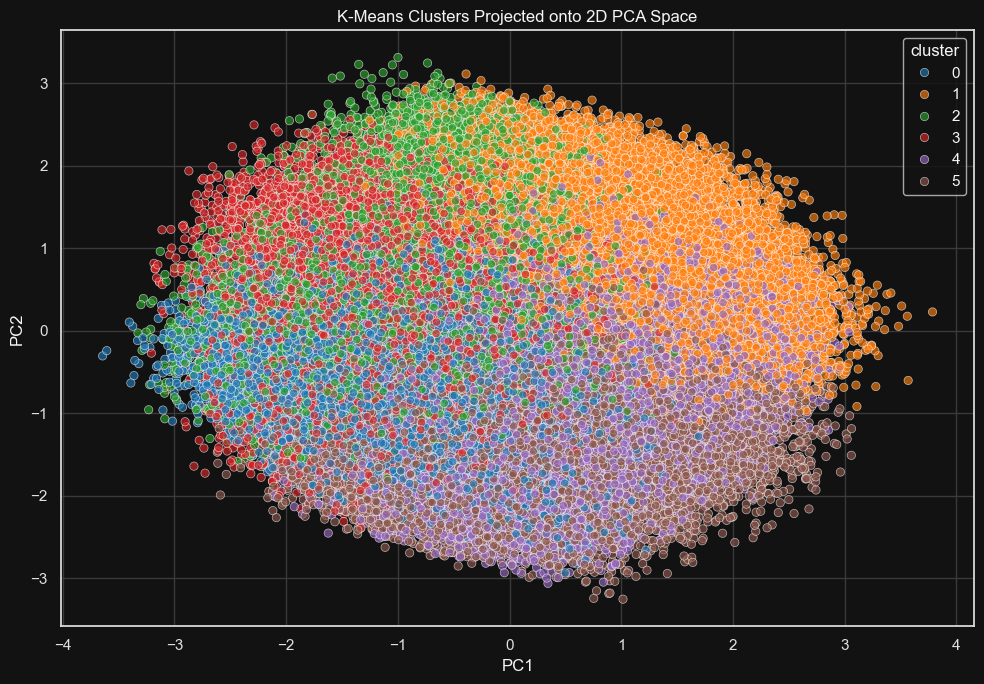

Saved: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\multivariate_analysis\kmeans_clusters_pca_space_dark.png
Explained variance ratio - PC1: 0.1677, PC2: 0.1675


In [ ]:
## Reduce high-dimensional cluster features to 2 PCs for visualization.
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_cluster_scaled)

pca_plot_df = pd.DataFrame({
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1],
    "cluster": cluster_df["cluster"].values,
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_plot_df, x="PC1", y="PC2", hue="cluster", palette="tab10", alpha=0.65)
plt.title("K-Means Clusters Projected onto 2D PCA Space")
plt.tight_layout()

pca_clusters_path = results_dir / "kmeans_clusters_pca_space_dark.png"
plt.savefig(pca_clusters_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {pca_clusters_path.resolve()}")

## Report variance captured by the first two principal components.
explained = pca.explained_variance_ratio_
print(f"Explained variance ratio - PC1: {explained[0]:.4f}, PC2: {explained[1]:.4f}")

## Step 7: Multivariate Insights Template

Use results above to summarize:
- Which variables jointly contribute most to ROI in the regression model?
- How strong is predictive fit (R^2, MAE, RMSE) and what does that imply?
- How many meaningful campaign clusters were identified and how are they different?
- Which cluster profile should be prioritized for budget allocation?

## Summary

This notebook completed multivariate analysis on the cleaned dataset using:
- simultaneous numeric relationship inspection
- multiple linear regression for ROI
- unsupervised clustering and PCA-based cluster visualization.

These outputs support higher-confidence decisions on channel mix, audience strategy, and campaign segmentation.

In [ ]:
## Compact multivariate summary export for logs/reporting pipelines.
summary_rows = []

## Core regression performance metrics.
summary_rows.extend([
    {"section": "regression_metrics", "group": "linear_regression", "metric": "r2", "value": r2},
    {"section": "regression_metrics", "group": "linear_regression", "metric": "mae", "value": mae},
    {"section": "regression_metrics", "group": "linear_regression", "metric": "rmse", "value": rmse},
    {"section": "regression_metrics", "group": "linear_regression", "metric": "train_rows", "value": len(X_train)},
    {"section": "regression_metrics", "group": "linear_regression", "metric": "test_rows", "value": len(X_test)},
])

## Top coefficient magnitudes indicate strongest linear contributions.
for _, row in coef_df.head(15).iterrows():
    summary_rows.append(
        {
            "section": "top_coefficients",
            "group": row["feature"],
            "metric": "coefficient",
            "value": row["coefficient"],
        }
    )

## Silhouette diagnostics and selected K.
for _, row in silhouette_df.sort_values("k").iterrows():
    summary_rows.append(
        {
            "section": "silhouette_scores",
            "group": f"k_{int(row['k'])}",
            "metric": "silhouette_score",
            "value": row["silhouette_score"],
        }
    )
summary_rows.append(
    {"section": "silhouette_scores", "group": "model_selection", "metric": "best_k", "value": best_k}
 )

## Cluster sizes and centroid-like means by cluster.
cluster_counts = cluster_df["cluster"].value_counts().sort_index()
for cluster_label, count in cluster_counts.items():
    summary_rows.append(
        {
            "section": "cluster_sizes",
            "group": f"cluster_{int(cluster_label)}",
            "metric": "count",
            "value": count,
        }
    )

cluster_means = cluster_df.groupby("cluster")[cluster_features].mean()
for cluster_label, row in cluster_means.iterrows():
    for feature in cluster_features:
        summary_rows.append(
            {
                "section": "cluster_feature_means",
                "group": f"cluster_{int(cluster_label)}",
                "metric": feature,
                "value": row[feature],
            }
        )

## PCA variance capture for the 2D cluster projection.
summary_rows.extend([
    {"section": "pca", "group": "variance", "metric": "pc1_explained_ratio", "value": explained[0]},
    {"section": "pca", "group": "variance", "metric": "pc2_explained_ratio", "value": explained[1]},
    {"section": "pca", "group": "variance", "metric": "pc1_pc2_total_ratio", "value": explained[0] + explained[1]},
])

multivariate_final_summary = pd.DataFrame(summary_rows)
multivariate_summary_csv_path = results_dir / "multivariate_final_summary.csv"
multivariate_final_summary.to_csv(multivariate_summary_csv_path, index=False)

print(f"Saved summary CSV: {multivariate_summary_csv_path.resolve()}")
multivariate_final_summary.head(15)

Saved summary CSV: C:\Users\hecto\OneDrive\Documentos\VSCode\py_marketing_eda\results\multivariate_analysis\multivariate_final_summary.csv


,section,group,metric,value
0,regression_metrics,linear_regression,r2,-0.000194
1,regression_metrics,linear_regression,mae,1.504420
2,regression_metrics,linear_regression,rmse,1.736742
3,regression_metrics,linear_regression,train_rows,150000.000000
4,regression_metrics,linear_regression,test_rows,50000.000000
5,top_coefficients,Conversion_Rate,coefficient,-0.055820
6,top_coefficients,Channel_Used_Facebook,coefficient,0.027553
7,top_coefficients,Target_Audience_Men 18-24,coefficient,-0.022680
8,top_coefficients,Target_Audience_Men 25-34,coefficient,0.019299
9,top_coefficients,Campaign_Type_Social Media,coefficient,-0.017667


## Executive Summary

The multivariate analysis indicates that, with the current feature set and linear assumptions, ROI is only weakly explainable. The multiple linear regression produced an `R^2` near zero (slightly negative), with moderate error (`MAE` and `RMSE`), which suggests that the model is not capturing strong predictive structure in ROI. Coefficient magnitudes are generally small, indicating no single dominant driver among the included numeric and encoded categorical variables.

Unsupervised segmentation selected **6 clusters** based on silhouette optimization, but silhouette values remain low, implying weak separation and overlapping groups rather than sharply distinct campaign segments. Even so, cluster profiles still provide useful directional archetypes: some groups combine stronger ROI with specific traffic and cost patterns, while others underperform despite high activity in selected metrics.

The PCA projection further supports this interpretation. The first two components explain roughly one-third of total variance, which is sufficient for visualization but not enough to represent the full multivariate structure. In practical terms, the analysis supports cautious, pattern-level interpretation rather than high-confidence causal conclusions.

Given the synthetic nature of the dataset, these results are best treated as validation of the analytical workflow (EDA, modeling, clustering, and reporting) rather than definitive market behavior. The strongest next step is to improve data realism and feature richness so that future multivariate models recover clearer signal and produce more actionable business guidance.